# Corrected CV-DV LCHS: Damped Harmonic Oscillator (CHO)

This notebook implements the **damped harmonic oscillator** toy example from
Das et al. (2025), Section 3.5.1, Equations (35)–(40), using **consistent
$\hbar=1$ conventions** throughout.

## CHO Problem

The damped harmonic oscillator is described by
$$\frac{d^2 x}{dt^2} + \gamma \frac{dx}{dt} + \omega^2 x = 0,$$
which, with $v = \dot{x}$, becomes the first-order system
$$\frac{d}{dt}\begin{bmatrix}x\\v\end{bmatrix}
= -\underbrace{\begin{bmatrix}\gamma/2 & -\omega\\ \omega & \gamma/2\end{bmatrix}}_{A}
\begin{bmatrix}x\\v\end{bmatrix}.$$
The Cartesian decomposition gives $L = (\gamma/2)I$ (dissipation) and
$H = -\omega Y$ (rotation), so the LCHS integral reads
$$u(T) = \left[\int g(k)\, e^{-iT(kL+H)}\,dk\right] u_0.$$

## Bug Fixes (relative to `LCHS CHO.ipynb`)

| Bug | Original | Fix |
|-----|----------|-----|
| **$\hbar=2$ gamma** | `gamma = exp(-2r') - exp(-2r)` | `gamma = 0.5*(exp(-2r') - exp(-2r))` |
| **$2\beta$ kernel** | `C_val = 2*pi*exp(-2*beta)` | `C_val = 2*pi*exp(-2**beta)` |
| **$\hat{x}/2$ operator** | `K_op = (a+a^dag)/2` | `K_op = (a+a^dag)/sqrt(2)` |

See `formed_math.tex` Section 8 for the full derivation of why these corrections are
needed. In brief: the paper (Eq. 6) writes the squeezed vacuum as
$\phi_r(x) = (2/\sigma^2\pi)^{1/4}e^{-x^2/\sigma^2}$, which is the $\hbar=2$ convention
where $\hat{x} = a+a^\dagger$. QuTiP uses $\hbar=1$ where
$\hat{x} = (a+a^\dagger)/\sqrt{2}$ and the squeezed vacuum is
$(1/\sigma^2\pi)^{1/4}e^{-x^2/(2\sigma^2)}$. The overlap integral’s Gaussian rate
picks up a factor of $1/2$: $\gamma_{\hbar=1} = \gamma_{\hbar=2}/2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite
from numpy.polynomial.hermite import hermgauss
from qutip import (basis, squeeze, tensor, sigmay,
                   identity, destroy, displace)
from scipy.special import gammaln

In [2]:
def get_lchs_states(beta, r_target, r_prime, N_dim, n_quad_points=200):
    """
    Calculate LCHS coefficients C_n via Gauss-Hermite quadrature and
    construct the preparation / post-selection states.

    Implements Paper Eq.(12):
        C_n = K_n * integral H_n(x/sigma') g(x) exp(-gamma x^2) dx

    With the hbar=1 correction:
        gamma_hbar1 = 0.5 * (exp(-2r') - exp(-2r))    [NOT gamma_hbar2]
        x_hat = (a + a^dag) / sqrt(2)                  [NOT a + a^dag]

    References:
        - Paper Eq.(6):  squeezed vacuum in hbar=2 form
        - Paper Eq.(12): coefficient integral with gamma_hbar2
        - Weedbrook et al., Rev. Mod. Phys. 84, 621 (2012), Sec. II:
          taxonomy of hbar conventions in quantum optics
    """
    print(f"1. Preparing States (N={N_dim}, r_target={r_target})...")

    # --- FIX 1: hbar=1 gamma (factor of 1/2) ---
    # Paper Eq.(12) uses gamma_hbar2 = e^{-2r'} - e^{-2r}.
    # In hbar=1 (QuTiP), the squeezed vacuum Gaussian is exp(-x^2/(2sigma^2)),
    # so the overlap rate becomes gamma_hbar1 = gamma_hbar2 / 2.
    # See formed_math.tex, Eq.(corrected-explicit) and formed_qutip.py:gamma_hbar1().
    gamma = 0.5 * (np.exp(-2 * r_prime) - np.exp(-2 * r_target))

    width_param = np.exp(r_prime)  # sigma' = e^{r'}
    scale_factor = np.sqrt(2) * width_param

    # Gauss-Hermite quadrature nodes and weights
    x_roots, weights = hermgauss(n_quad_points)
    p_points = x_roots * scale_factor  # k = sqrt(2) * sigma' * xi

    # --- FIX 2: kernel constant 2^beta, not 2*beta ---
    # Paper defines f(k) = e^{2^beta} / (2*pi*e^{(1+ik)^beta}),
    # hence g(k) = f(k)/(1-ik) with C_beta = 2*pi*exp(-2^beta).
    # The old code had exp(-2*beta) [multiplication], which is wrong.
    C_val = 2 * np.pi * np.exp(-(2.0 ** beta))
    term_exp = np.exp((1 + 1j * p_points) ** beta)
    denom_func = C_val * term_exp * (1 - 1j * p_points)

    # The GH weight w_i implicitly includes exp(-xi^2), which absorbs the
    # basis Gaussian from the Hermite function.  The 'excess' Gaussian
    # exp(-gamma * k^2) remains explicitly.
    target_part = np.exp(-gamma * p_points**2) / denom_func

    # Fock-space expansion coefficients
    cn_list = []
    sqrt_pi = np.sqrt(np.pi)
    basis_prefactor = 1.0 / np.sqrt(sqrt_pi * width_param)

    for n in range(N_dim):
        # Numerically stable 1/sqrt(2^n * n!)
        fock_norm = np.exp(-0.5 * (n * np.log(2) + gammaln(n + 1)))
        H_val = eval_hermite(n, p_points / width_param)

        integrand = target_part * (basis_prefactor * fock_norm * H_val)
        val = np.sum(weights * integrand) * scale_factor
        cn_list.append(val)

    # Construct QuTiP state objects
    cn_array = np.array(cn_list)
    psi_seed = sum([cn_array[n] * basis(N_dim, n) for n in range(N_dim)]).unit()

    # Apply squeezing: |psi> = S(r') * |seed>
    S_op_prime = squeeze(N_dim, r_prime)
    psi_osc_init = S_op_prime * psi_seed

    # Post-selection state: |phi> = S(r) |0>
    S_op_target = squeeze(N_dim, r_target)
    phi_post = S_op_target * basis(N_dim, 0)

    print("   States ready.")
    return psi_osc_init, phi_post

In [3]:
def run_simulation(omega, gamma_damp, T_step, n_steps, N_dim, psi_osc_init, phi_post):
    """
    Run the Trotterized CV-DV LCHS simulation for the CHO.

    The CHO coefficient matrix A has Cartesian decomposition:
        L = (gamma/2) I    (PSD dissipative part)
        H = -omega Y       (Hamiltonian rotation)

    The joint evolution couples the oscillator position operator x_hat
    to the qubit system via exp(-i T x_hat (x) A).
    """
    print("2. Running Simulation...")

    # Qubit operators for L and H (Paper Eq. 37-38)
    L_coeff = 0.5 * gamma_damp
    H_coeff = -omega

    Op_L = L_coeff * identity(2)   # L = (gamma/2) I
    Op_H = H_coeff * sigmay()      # H = -omega Y

    a = destroy(N_dim)

    # --- FIX 3: hbar=1 position operator ---
    # The paper uses x_hat = a + a^dag (hbar=2).  QuTiP operates in hbar=1
    # where x_hat = (a + a^dag) / sqrt(2), satisfying [x_hat, p_hat] = i.
    # The original notebook incorrectly used (a + a^dag) / 2.
    # See Braunstein & van Loock, Rev. Mod. Phys. 77, 513 (2005).
    K_op = (a.dag() + a) / np.sqrt(2.0)

    kappa = phi_post.dag() * K_op * psi_osc_init
    print(f"   <phi|x_hat|psi> = {kappa}")

    Id_osc = identity(N_dim)
    Ham_Joint = tensor(K_op, Op_L)       # x_hat (x) L
    Ham_Single = tensor(Id_osc, Op_H)    # I_osc (x) H

    # First-order Trotter step: exp(-i dt (x(x)L + I(x)H)) ~ exp(-i dt x(x)L) exp(-i dt I(x)H)
    U_joint = (-1j * T_step * Ham_Joint).expm()
    U_single = (-1j * T_step * Ham_Single).expm()
    U_step = U_joint * U_single

    # Initial qubit state |0> = position component
    psi_qubit_0 = basis(2, 0)
    psi_current = tensor(psi_osc_init, psi_qubit_0)

    # Projector: <phi_post| (x) I_qubit
    projector_osc_bra = tensor(phi_post.dag(), identity(2))

    u_vals = []  # Position x(t)
    v_vals = []  # Velocity v(t)
    times = np.linspace(0, n_steps * T_step, n_steps)

    # Normalization from t=0
    vec_0 = (projector_osc_bra * psi_current).full()
    norm_factor = np.linalg.norm(vec_0)
    print(f"   Normalization Factor: {norm_factor:.4f}")

    for _ in range(n_steps):
        qubit_vec = (projector_osc_bra * psi_current).full()
        u_t = np.real(qubit_vec[0][0])
        v_t = np.real(qubit_vec[1][0])
        u_vals.append(u_t)
        v_vals.append(v_t)
        psi_current = U_step * psi_current

    return times, u_vals, v_vals

In [4]:
def main():
    # Parameters (same as original LCHS CHO.ipynb for comparison)
    omega = 10.0
    beta = 0.8
    # r_target = 8
    # r_prime = 6
    r_target = 0.8
    r_prime = 0.1
    N_dim = 100
    T_step = 0.05
    n_steps = 100
    gamma_damp = 0.2

    # 1. Prepare LCHS states
    psi_init, phi_post = get_lchs_states(beta, r_target, r_prime, N_dim)

    # 2. Run Trotterized simulation
    times, u_vals, v_vals = run_simulation(
        omega, gamma_damp, T_step, n_steps, N_dim, psi_init, phi_post
    )

    # 3. Classical reference solution
    # From Paper Eq.(35): x(t) = exp(-gamma*t/2) cos(omega*t), v(t) = -exp(-gamma*t/2) sin(omega*t)
    exact_u = np.exp(-0.5 * gamma_damp * times) * np.cos(omega * times)
    exact_v = -np.exp(-0.5 * gamma_damp * times) * np.sin(omega * times)

    # 4. Visualization
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.plot(times, u_vals, 'b.-', label='LCHS (Qubit |0>)', linewidth=2)
    plt.plot(times, exact_u, 'k--', label=r'Classical $e^{-\gamma t/2}\cos(\omega t)$', alpha=0.6)
    plt.title("Position $u(t)$")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.plot(times, v_vals, 'r.-', label='LCHS (Qubit |1>)', linewidth=2)
    plt.plot(times, exact_v, 'k--', label=r'Classical $-e^{-\gamma t/2}\sin(\omega t)$', alpha=0.6)
    plt.title("Velocity $v(t)$")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

1. Preparing States (N=100, r_target=0.8)...
   States ready.
2. Running Simulation...
   <phi|x_hat|psi> = (1.235488022422361e-17+0.012070554034376842j)
   Normalization Factor: 0.9485


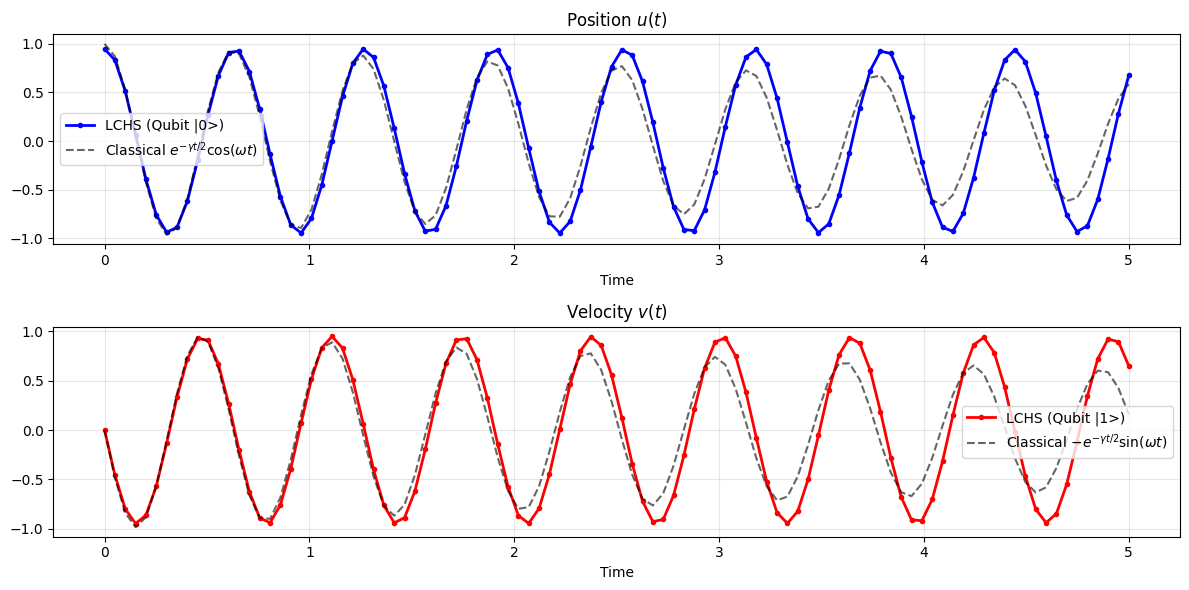

In [5]:
if __name__ == "__main__":
    main()

## Convention Summary

This notebook uses the **$\hbar=1$ convention** consistently:

| Quantity | Paper ($\hbar=2$) | This notebook ($\hbar=1$) |
|----------|-------------------|---------------------------|
| Position operator | $\hat{x} = a + a^\dagger$ | $\hat{x} = (a + a^\dagger)/\sqrt{2}$ |
| Squeezed vacuum | $(2/\sigma^2\pi)^{1/4} e^{-x^2/\sigma^2}$ | $(1/\sigma^2\pi)^{1/4} e^{-x^2/(2\sigma^2)}$ |
| Overlap $\gamma$ | $e^{-2r'} - e^{-2r}$ | $\frac{1}{2}(e^{-2r'} - e^{-2r})$ |
| Kernel constant | $C_\beta = 2\pi e^{-2^\beta}$ | Same (convention-independent) |

The three bugs in the original `LCHS CHO.ipynb` are:
1. **$\gamma$ without factor of $1/2$**: Paper Eq.(12) uses $\hbar=2$ gamma; QuTiP requires $\gamma_{\hbar=1} = \gamma_{\hbar=2}/2$.
2. **$2\beta$ instead of $2^\beta$** in the kernel constant $C_\beta$ (multiplication vs exponentiation).
3. **$(a+a^\dagger)/2$ instead of $(a+a^\dagger)/\sqrt{2}$** for the position operator.

### References
- Das, Zheng, Dutta, Li, Liu, *Hybrid Oscillator-Qubit LCHS* (2025) — `res_base/Hybrid_CV_DV_LCHS.pdf`
- Weedbrook et al., *Gaussian quantum information*, Rev. Mod. Phys. **84**, 621 (2012) — Sec. II on $\hbar$ conventions
- Braunstein & van Loock, *Quantum information with continuous variables*, Rev. Mod. Phys. **77**, 513 (2005)
- Full derivation: `formed_math.tex`, Section 8